In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/project_3/uber_cleaned.xlsx')

In [ ]:
df.head()

,Row_ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,...,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek
0,0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday
1,1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,...,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday
2,2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,...,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday
3,3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,...,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday
4,4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,...,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday


## Q4) Booking Trends Over Time

In [ ]:
weekly = df.groupby('DayOfWeek').size().reset_index(name='Total_Bookings')
weekly

,DayOfWeek,Total_Bookings
0,Friday,21397
1,Monday,21644
2,Saturday,21542
3,Sunday,21398
4,Thursday,21215
5,Tuesday,21391
6,Wednesday,21413


In [ ]:
df['Month'] = df['Datetime'].dt.to_period('M').astype(str)
monthly = df.groupby('Month').size().reset_index(name='Total_Bookings')
monthly

,Month,Total_Bookings
0,2024-01,12861
1,2024-02,11927
2,2024-03,12719
3,2024-04,12199
4,2024-05,12778
5,2024-06,12440
6,2024-07,12897
7,2024-08,12636
8,2024-09,12248
9,2024-10,12651


In [ ]:
# Completed vs Cancelled vs Incomplete vs No Driver Found — monthly
status_monthly = df.groupby(['Month', 'Booking Status']).size().unstack(fill_value=0)
status_monthly

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Month,,,,,
2024-01,893,2324,7951,808,885
2024-02,838,2190,7368,681,850
2024-03,906,2240,7954,727,892
2024-04,779,2221,7632,725,842
2024-05,919,2317,7905,768,869
2024-06,883,2206,7757,738,856
2024-07,932,2332,7926,803,904
2024-08,834,2351,7780,735,936
2024-09,894,2165,7542,743,904


In [ ]:
# Cancellation rate trend (KPI, not raw count)
status_monthly['Cancellation_Rate_%'] = (
    (status_monthly.get('Cancelled by Customer', 0) + status_monthly.get('Cancelled by Driver', 0))
    / status_monthly.sum(axis=1) * 100
).round(2)
status_monthly['Cancellation_Rate_%']

,Cancellation_Rate_%
Month,
2024-01,25.01
2024-02,25.39
2024-03,24.73
2024-04,24.59
2024-05,25.32
2024-06,24.83
2024-07,25.31
2024-08,25.21
2024-09,24.98


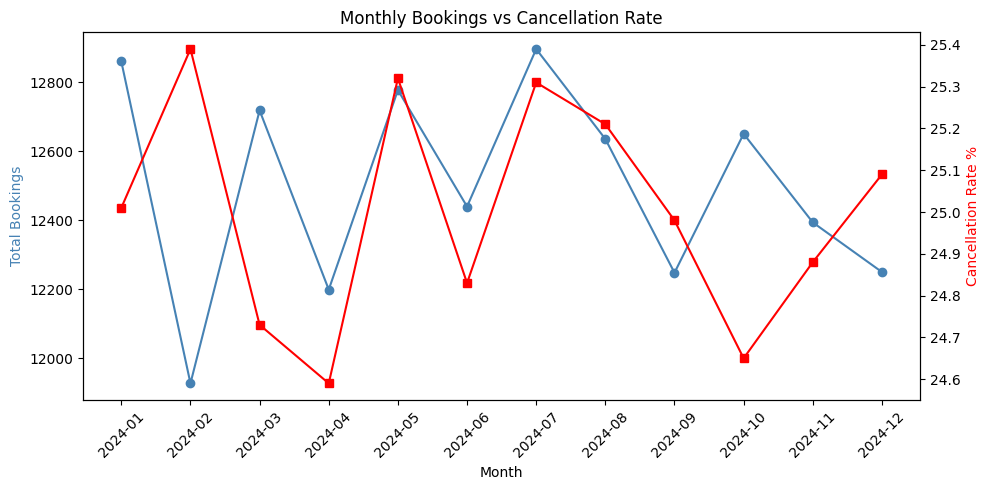

In [ ]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(monthly['Month'], monthly['Total_Bookings'], color='steelblue', marker='o', label='Total Bookings')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Bookings', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(status_monthly.index, status_monthly['Cancellation_Rate_%'], color='red', marker='s', label='Cancellation Rate %')
ax2.set_ylabel('Cancellation Rate %', color='red')

plt.title('Monthly Bookings vs Cancellation Rate')
fig.tight_layout()
plt.show()

## Q4) How do booking trends change over time?

**Insight:**
Monthly bookings remain stable throughout 2024, ranging from **11,927 to 12,897** (only about an **8% variation**). There is no clear upward or downward trend. The cancellation rate is also consistent at around **25% every month** (24.6%–25.4%).

Among all failed bookings, **driver cancellations** are the biggest contributor, averaging **about 2,270 per month**. This is around **2.5 times higher** than customer cancellations (~880) or **No Driver Found** cases ( ~870). This indicates a consistent operational issue rather than a seasonal one.

**Recommendation:**
Since demand and cancellations remain stable throughout the year, seasonal campaigns are unlikely to improve performance. Instead, focus on reducing the **year-round driver cancellation rate**, as it is the main reason bookings fail. Improving driver reliability will likely have a greater impact than increasing demand.

## Q5) Driver Utilization

In [ ]:
# 1. Booking Status breakdown (where is supply leaking?)
status_counts = df['Booking Status'].value_counts(normalize=True).mul(100).round(2)
status_counts

,proportion
Booking Status,
Completed,62.0
Cancelled by Driver,18.0
No Driver Found,7.0
Cancelled by Customer,7.0
Incomplete,6.0


In [ ]:
# 2. Driver cancellation reasons (only where drivers cancelled)
driver_cancel_reasons = df[df['Booking Status'] == 'Cancelled by Driver']['Driver Cancellation Reason'].value_counts()
driver_cancel_reasons

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


In [ ]:
# 3. Incomplete ride reasons
incomplete_reasons = df[df['Incomplete Rides'] == 1]['Incomplete Rides Reason'].value_counts()
incomplete_reasons

,count
Incomplete Rides Reason,
Customer Demand,3040
Vehicle Breakdown,3012
Other Issue,2948


In [ ]:
# 4. Avg VTAT (Vehicle Turnaround Time) & CTAT (Customer Turnaround Time) by Vehicle Type
vtat_ctat_by_vehicle = df.groupby('Vehicle Type')[['Avg VTAT', 'Avg CTAT']].mean().round(2).sort_values('Avg VTAT', ascending=False)
vtat_ctat_by_vehicle

,Avg VTAT,Avg CTAT
Vehicle Type,,
Uber XL,8.58,29.21
Bike,8.50,29.20
eBike,8.48,29.18
Go Mini,8.47,29.16
Auto,8.45,29.14
Premier Sedan,8.44,29.22
Go Sedan,8.40,29.04


In [ ]:
# 5. Demand by Vehicle Type (which segment is over/under-supplied)
demand_by_vehicle = df['Vehicle Type'].value_counts()
demand_by_vehicle

,count
Vehicle Type,
Auto,37419
Go Mini,29806
Go Sedan,27141
Bike,22517
Premier Sedan,18111
eBike,10557
Uber XL,4449


In [ ]:
# 6. "No Driver Found" rate by Vehicle Type — direct supply gap indicator
no_driver = df[df['Booking Status'] == 'No Driver Found']['Vehicle Type'].value_counts()
no_driver_rate = (no_driver / demand_by_vehicle * 100).round(2).sort_values(ascending=False)
no_driver_rate

,count
Vehicle Type,
Go Sedan,7.22
Auto,7.16
Uber XL,7.08
eBike,7.07
Premier Sedan,7.07
Go Mini,6.76
Bike,6.67


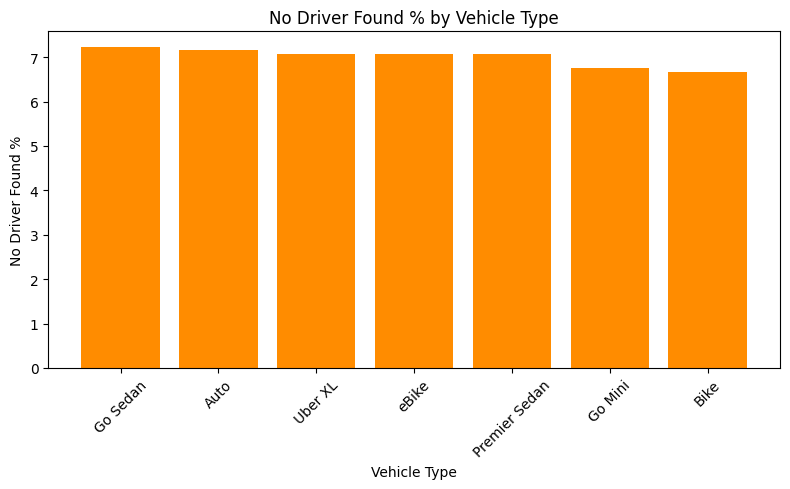

In [ ]:
no_driver_rate_sorted = no_driver_rate.sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(no_driver_rate_sorted.index, no_driver_rate_sorted.values, color='darkorange')
plt.title('No Driver Found % by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('No Driver Found %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Q5) How can Uber improve driver utilization?

**Insight:**

Only **62% of bookings are successfully completed**, meaning **38% do not result in a ride**.

The largest contributor is **driver cancellations (18%)**, which is much higher than **customer cancellations (7%)** or **No Driver Found (7%)**. Driver cancellation reasons (customer-related issues, sickness, vehicle problems, and overcrowding) occur in almost equal numbers, with no single reason standing out. This suggests the problem is **system-wide rather than caused by one specific issue**.

Vehicle performance is also very similar. **VTAT (8.4–8.6 minutes)** and **CTAT (29.0–29.2 minutes)** show almost no difference across vehicle types. Likewise, the **No Driver Found** rate varies only slightly (6.67%–7.22%).

**Recommendation:**
Reducing **driver cancellations** should be the top priority, as it is the largest controllable cause of failed bookings. Since cancellation reasons are evenly distributed, the issue is more likely related to **driver policies or incentives** than to a specific vehicle type or route.

Consider strengthening driver cancellation policies and reviewing common reasons such as **Customer Related Issue** and **Sickness** to identify possible misuse. Fleet composition is not a priority, as vehicle types perform almost identically.

---

## Q6) Factors Driving Booking Value

In [4]:
completed = df[df['Booking Status'] == 'Completed'].copy()

In [5]:
# 1. Booking Value vs Ride Distance (correlation)
corr_distance = completed['Booking Value'].corr(completed['Ride Distance']).round(2)
corr_distance

np.float64(0.01)

In [6]:
# 2. Avg Booking Value by Vehicle Type
value_by_vehicle = completed.groupby('Vehicle Type')['Booking Value'].mean().round(2).sort_values(ascending=False)
value_by_vehicle

,Booking Value
Vehicle Type,
Go Sedan,512.03
Premier Sedan,509.57
Bike,509.11
Go Mini,507.38
Auto,506.48
Uber XL,505.30
eBike,503.46


In [ ]:
# 3. Time slot buckets from Hour
def time_slot(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'

completed['Time_Slot'] = completed['Hour'].apply(time_slot)
value_by_timeslot = completed.groupby('Time_Slot')['Booking Value'].mean().round(2).sort_values(ascending=False)
value_by_timeslot

,Booking Value
Time_Slot,
Night,510.83
Morning,509.15
Evening,508.13
Afternoon,505.38


In [ ]:
# 4. Avg Booking Value by Pickup Location (top 10 only — avoid clutter)
value_by_pickup = completed.groupby('Pickup Location')['Booking Value'].agg(['mean','count']).round(2)
value_by_pickup = value_by_pickup[value_by_pickup['count'] >= 30].sort_values('mean', ascending=False).head(10)
value_by_pickup

,mean,count
Pickup Location,,
Greater Noida,561.50,516
Pataudi Chowk,551.75,556
Kherki Daula Toll,543.88,513
Anand Vihar ISBT,542.69,511
Tughlakabad,542.43,552
Udyog Vihar,540.03,539
Rohini West,539.50,519
Arjangarh,538.93,486
Dilshad Garden,538.23,501


In [ ]:
# 5. Avg Booking Value by Payment Method
value_by_payment = completed.groupby('Payment Method')['Booking Value'].mean().round(2).sort_values(ascending=False)
value_by_payment

,Booking Value
Payment Method,
Credit Card,510.06
Cash,508.61
UPI,508.55
Uber Wallet,505.90
Debit Card,505.86


In [ ]:
# 6. Booking Value: Completed vs Incomplete (revenue leakage)
value_by_status = df.groupby('Booking Status')['Booking Value'].mean().round(2)
value_by_status

,Booking Value
Booking Status,
Cancelled by Customer,NaN
Cancelled by Driver,NaN
Completed,508.18
Incomplete,509.51
No Driver Found,NaN


## Q6) Which factors contribute to higher booking value?

**Insight:**
The correlation between **Booking Value** and **Ride Distance** is **0.01**, indicating **virtually no relationship**. In this dataset, longer rides do not necessarily generate higher fares.

Average booking value is also very similar across:

* **Vehicle Type:** ₹503–₹512
* **Time Slot:** ₹505–₹511
* **Payment Method:** ₹506–₹510

The only factor showing meaningful variation is **Pickup Location**. Locations such as **Greater Noida (₹561.50)** and **Pataudi Chowk (₹551.75)** have booking values around **6–10% higher** than the overall average (~₹508). These figures are based on locations with at least **30 completed rides** for reliability.

There is also almost no difference in booking value between **completed** and **incomplete** bookings (₹508.18 vs. ₹509.51).

**Recommendation:**
Booking value is **not significantly influenced by ride distance, vehicle type, time of day, or payment method**. The strongest pricing signal comes from **pickup location**, suggesting that fares may be influenced more by **zone-based pricing** than by ride characteristics.

---

## Overall Executive Summary

The analysis of the **150K Uber ride dataset** shows a **stable demand pattern but inefficient operations**. Monthly bookings remain consistent throughout the year with **no seasonal trend**, while approximately **38% of bookings fail to complete**.

The main operational challenge is **driver cancellations (18%)**, which are significantly higher than customer cancellations or driver availability issues. This makes driver-side reliability the most important area for improvement.

In addition, **vehicle type and time of day have little impact** on turnaround time or booking value. The only factor that consistently affects booking value is **pickup location**, indicating a possible **zone-based pricing model**.

**Key Recommendations:**

* Prioritize reducing **driver cancellations** through improved policies, incentives, and monitoring.
* Investigate high-frequency driver cancellation reasons for potential policy gaps or misuse.
* Explore **zone-based pricing** further, as pickup location has a stronger influence on booking value than ride distance.
* Avoid seasonal demand campaigns, as booking demand remains stable throughout the year.